In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [14]:
df_heart = pd.read_csv("heart.csv")
df_heart = pd.get_dummies(df_heart, drop_first=True)
X = df_heart.drop("target", axis=1)
y = df_heart["target"]

y_heart = df_heart['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

heart_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,        
    min_samples_split=20, 
    min_samples_leaf=5,
    random_state=42
)
heart_model.fit(X_train, y_train)

print("Heart Accuracy:", accuracy_score(y_test, heart_model.predict(X_test)))

Heart Accuracy: 0.8975609756097561


In [3]:
df_diabetes = pd.read_csv("diabetes.csv")

X = df_diabetes.drop("Outcome", axis=1)
y = df_diabetes["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

diabetes_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=90,
    min_samples_leaf=5,
    random_state=42
)
diabetes_model.fit(X_train, y_train)

print("Diabetes Accuracy:", accuracy_score(y_test, diabetes_model.predict(X_test)))

Diabetes Accuracy: 0.7922077922077922


In [4]:
df_kidney = pd.read_csv("kidney.csv")

df_kidney['classification'] = df_kidney['classification'].str.strip().str.lower()

X = df_kidney[['age','bp','sg','al','su','bgr','bu','sc','hemo']]

X = X.replace("?", np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

y = LabelEncoder().fit_transform(df_kidney['classification'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

kidney_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

kidney_model.fit(X_train, y_train)

print("Kidney Accuracy:", accuracy_score(y_test, kidney_model.predict(X_test)))

Kidney Accuracy: 0.9875


In [5]:
df_liver = pd.read_csv("liver.csv")

# Clean column names
df_liver.columns = df_liver.columns.str.strip()

# Fix gender (text → number)
df_liver['gender'] = df_liver['gender'].map({
    'Male': 1,
    'Female': 0
})

# Select features (same style as kidney)
X = df_liver[['age','gender','tot_bilirubin','direct_bilirubin','tot_proteins','albumin','ag_ratio','sgpt','sgot','alkphos']]

# Handle missing / bad values
X = X.replace("?", np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

# Target
y = df_liver['is_patient']

# Convert target if needed
y = y.replace({2: 0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model (same tuning style as kidney)
liver_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# Train
liver_model.fit(X_train, y_train)
from sklearn.metrics import classification_report

# Accuracy
print("Liver Accuracy:", accuracy_score(y_test, liver_model.predict(X_test)))

Liver Accuracy: 0.7350427350427351


In [6]:
df_anemia = pd.read_csv("anemia.csv")

# Clean column names
df_anemia.columns = df_anemia.columns.str.strip()

# Features
X = df_anemia[['Gender','Hemoglobin','MCH','MCHC','MCV']]

# Encode Gender
X['Gender'] = X['Gender'].map({
    'Male': 1,
    'Female': 0,
    'M': 1,
    'F': 0
})

# Handle missing values
X = X.replace("?", np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

# Target
y = df_anemia['Result']

# Encode target
y = LabelEncoder().fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model (same kidney style)
anemia_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

# Train
anemia_model.fit(X_train, y_train)

# Accuracy
print("Anemia Accuracy:", accuracy_score(y_test, anemia_model.predict(X_test)))

Anemia Accuracy: 0.9192982456140351


In [17]:
df_obesity = pd.read_csv("obesity.csv")

# Clean column names
df_obesity.columns = df_obesity.columns.str.strip()

# 🔥 Encode categorical columns
df_obesity['Gender'] = df_obesity['Gender'].map({'Male':1, 'Female':0})

df_obesity['family_history'] = df_obesity['family_history'].map({'yes':1, 'no':0})
df_obesity['FAVC'] = df_obesity['FAVC'].map({'yes':1, 'no':0})
df_obesity['SMOKE'] = df_obesity['SMOKE'].map({'yes':1, 'no':0})
df_obesity['SCC'] = df_obesity['SCC'].map({'yes':1, 'no':0})

# Multi-category encoding
df_obesity['CAEC'] = LabelEncoder().fit_transform(df_obesity['CAEC'])
df_obesity['CALC'] = LabelEncoder().fit_transform(df_obesity['CALC'])
df_obesity['MTRANS'] = LabelEncoder().fit_transform(df_obesity['MTRANS'])

# Features
X = df_obesity[['Gender','Age','Height','Weight','family_history','FAVC',
                'FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS']]

# Clean values
X = X.replace("?", np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

# Target
y = LabelEncoder().fit_transform(df_obesity['Obesity'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
le_caec = LabelEncoder()
df_obesity['CAEC'] = le_caec.fit_transform(df_obesity['CAEC'])
# Model (same style)
obesity_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=40,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# Train
obesity_model.fit(X_train, y_train)

# Accuracy
print("Obesity Accuracy:", accuracy_score(y_test, obesity_model.predict(X_test)))

Obesity Accuracy: 0.8747044917257684


In [51]:
# Kidney
kidney_features = ['age','bp','sg','al','su','bgr','bu','sc','hemo']

# Diabetes (replace with your real diabetes columns)
diabetes_features = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

# Heart (replace with your heart columns)
heart_features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak']

# Liver
liver_features = ['age','gender','tot_bilirubin','direct_bilirubin','tot_proteins',
                  'albumin','ag_ratio','sgpt','sgot','alkphos']

# Anemia
anemia_features = ['Gender','Hemoglobin','MCH','MCHC','MCV']

# Obesity
obesity_features = ['Gender','Age','Height','Weight','family_history','FAVC',
                    'FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS']

In [86]:
def predict_all(patient):
    results = {}

    kidney_input = pd.DataFrame([patient['kidney']], columns=kidney_features)
    diabetes_input = pd.DataFrame([patient['diabetes']], columns=diabetes_features)
    heart_input = pd.DataFrame([patient['heart']], columns=heart_features)
    heart_input = heart_input.reindex(columns=heart_model.feature_names_in_, fill_value=0)
    liver_input = pd.DataFrame([patient['liver']], columns=liver_features)
    anemia_input = pd.DataFrame([patient['anemia']], columns=anemia_features)
    obesity_input = pd.DataFrame([patient['obesity']], columns=obesity_features)
    obesity_input['CAEC'] = le_caec.transform(obesity_input['CAEC'])

    results['Kidney'] = kidney_model.predict_proba(kidney_input)[0][1]
    results['Diabetes'] = diabetes_model.predict_proba(diabetes_input)[0][1]
    results['Heart'] = heart_model.predict_proba(heart_input)[0][1]
    results['Liver'] = liver_model.predict_proba(liver_input)[0][1]
    results['Anemia'] = anemia_model.predict_proba(anemia_input)[0][1]
    results['Obesity'] = obesity_model.predict(obesity_input)[0]

    return results

In [87]:
def generate_summary(results):
    summary = "\n🥗 ---- NutriScan Health Insights ----\n\n"

    for disease, risk in results.items():
        if disease != "Obesity":
            if risk > 0.6:
                status = "⚠️ Needs Attention"
            elif risk > 0.4:
                status = "🟡 Moderate"
            else:
                status = "✅ Good"

            summary += f"{disease:<10}: {status} ({round(risk*100,1)}%)\n"
        else:
            if risk == 0:
                level = "Normal"
            elif risk == 1:
                level = "Slightly Overweight"
            elif risk in [2,3]:
                level = "Overweight"
            else:
                level = "High Obesity"

            summary += f"Obesity   : {level}\n"

    return summary

In [88]:
def generate_diet(results):
    diet = "\n🍽️ ---- Personalized Diet Plan ----\n\n"

    if results['Diabetes'] > 0.6:
        diet += "🥦 Low Sugar Plan:\n- Avoid sweets\n- Add fiber-rich foods (oats, vegetables)\n\n"

    if results['Heart'] > 0.6:
        diet += "❤️ Heart Friendly Diet:\n- Avoid fried food\n- Eat oats, almonds, walnuts\n\n"

    if results['Kidney'] > 0.6:
        diet += "💧 Kidney Care Diet:\n- Reduce salt intake\n- Control protein\n\n"

    if results['Liver'] > 0.6:
        diet += "🍃 Liver Detox Plan:\n- Avoid alcohol\n- Eat leafy greens\n\n"

    if results['Anemia'] > 0.6:
        diet += "🩸 Iron Boost Diet:\n- Spinach, dates, jaggery\n- Include vitamin C\n\n"

    if results['Obesity'] >= 2:
        diet += "⚖️ Weight Loss Plan:\n- Calorie deficit\n- High protein diet\n- Daily exercise\n\n"

    return diet

In [89]:
import matplotlib.pyplot as plt

def plot_results(results):
    diseases = []
    values = []

    for k, v in results.items():
        if k != "Obesity":
            diseases.append(k)
            values.append(v*100)

    plt.figure(figsize=(8,5))

    bars = plt.bar(diseases, values)

    # color based on risk
    for i, v in enumerate(values):
        if v > 60:
            bars[i].set_color('red')
        elif v > 40:
            bars[i].set_color('orange')
        else:
            bars[i].set_color('green')

    plt.title("Health & Nutrition Analysis", fontsize=14, fontweight='bold')
    plt.ylabel("Risk (%)")
    plt.xlabel("Diseases")

    # add values on top
    for i, v in enumerate(values):
        plt.text(i, v + 1, f"{round(v,1)}%", ha='center')

    plt.ylim(0,100)
    plt.show()

In [90]:
def plot_pie(results):
    labels = []
    sizes = []

    for k, v in results.items():
        if k != "Obesity":
            labels.append(k)
            sizes.append(v)

    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.title("Overall Risk Distribution")
    plt.show()

In [91]:
def plot_horizontal(results):
    diseases = []
    values = []

    for k, v in results.items():
        if k != "Obesity":
            diseases.append(k)
            values.append(v*100)

    plt.figure(figsize=(8,5))
    plt.barh(diseases, values)

    plt.title("Health Risk Overview")
    plt.xlabel("Risk %")

    plt.xlim(0,100)
    plt.show()

In [92]:
patient = {
    "kidney": [50,120,1.02,1,0,150,40,1.2,15],
    "diabetes": [5,120,70,20,80,25,0.5,30],
    "heart": [55,1,3,130,250,0,1,150,0,2],
    "liver": [45,1,1.2,0.5,6.5,3.0,0.8,40,35,200],
    "anemia": [1,12,30,33,85],
    "obesity": [1,25,170,80,1,1,2,3,2,1,2,0,1,1,1,2]
}

results = predict_all(patient)

print(generate_summary(results))
print(generate_diet(results))


🥗 ---- NutriScan Health Insights ----

Kidney    : 🟡 Moderate (48.5%)
Diabetes  : ✅ Good (16.3%)
Heart     : ⚠️ Needs Attention (64.2%)
Liver     : 🟡 Moderate (44.2%)
Anemia    : ⚠️ Needs Attention (72.9%)
Obesity   : High Obesity


🍽️ ---- Personalized Diet Plan ----

❤️ Heart Friendly Diet:
- Avoid fried food
- Eat oats, almonds, walnuts

🩸 Iron Boost Diet:
- Spinach, dates, jaggery
- Include vitamin C

⚖️ Weight Loss Plan:
- Calorie deficit
- High protein diet
- Daily exercise




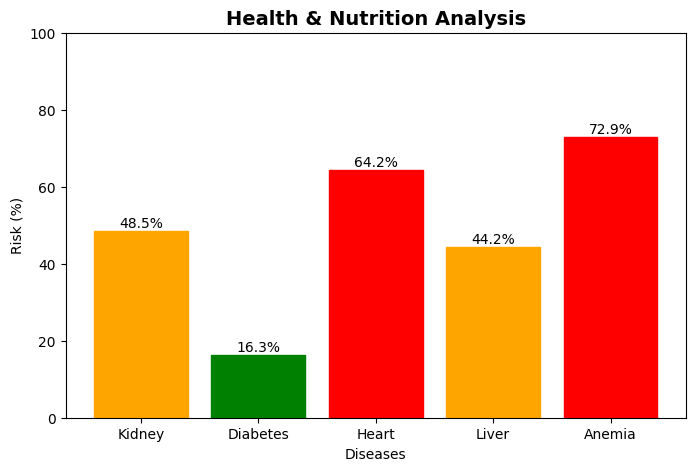

In [93]:
plot_results(results)

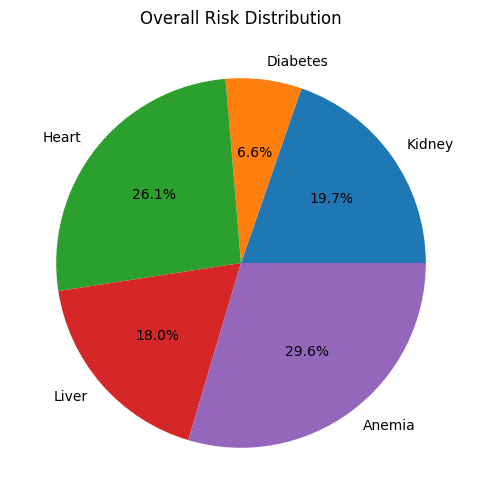

In [94]:
plot_pie(results)

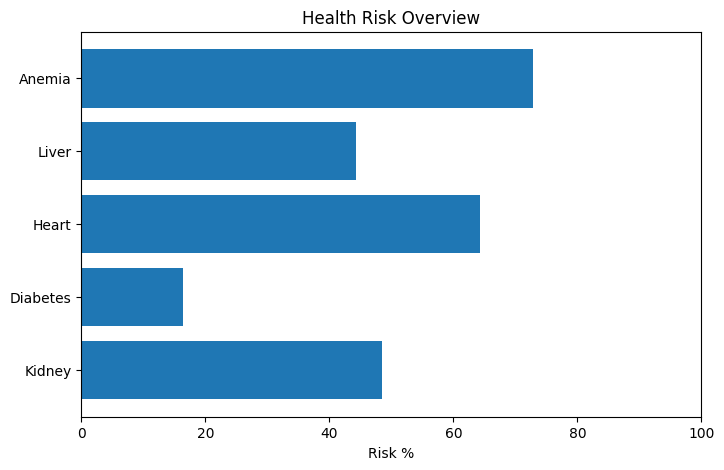

In [95]:
plot_horizontal(results)